# Residual study

`scp fermi:~/kerr/toby_files/toby_v3.* .`

In [1]:
%reset -f
%run pylib/tools dark
from utilities.skymaps import AITfigure
from utilities.ipynb_docgen import show, show_fig
from importlib import reload
from pylib import kerr_funcs; reload(kerr_funcs)
from pylib.kerr_funcs import *
pixel_table = PixelTable('files/kerr/toby_v3')

Loaded Kerr model from "files/kerr/toby_v3.npz":
            43 bands Band(0, 4): psf0@1.33 GeV nside 64 occ 1.000 ... Band(3, 11): psf3@74.99 GeV nside 2048 occ 0.000
            206,555,017 photons
            8,241,643 pixels
            


## plot residuals_for 1.33 GeV 

<utilities.ipynb_docgen.doc_formatter.<locals>.MimeBundleObject at 0xf540d7160bf0>
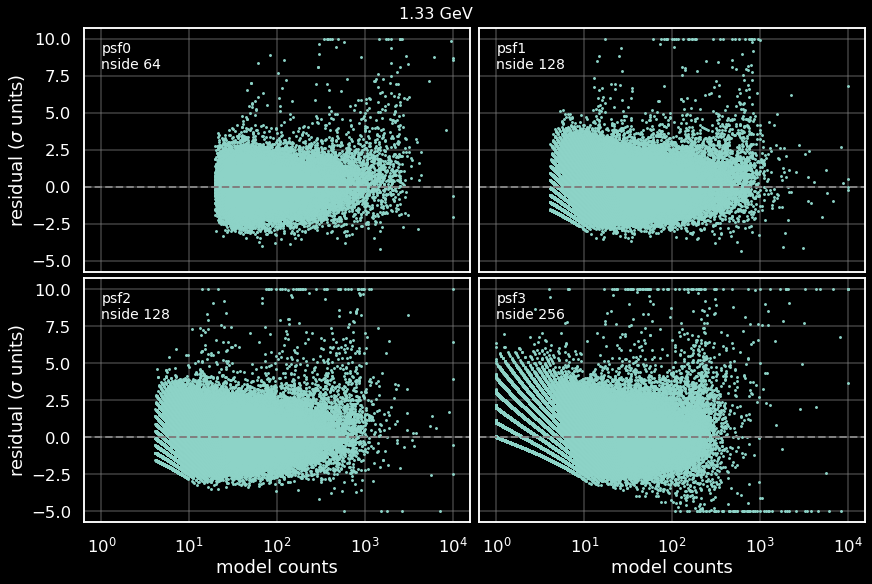

<utilities.ipynb_docgen.doc_formatter.<locals>.MimeBundleObject at 0xf540c2a73fb0>
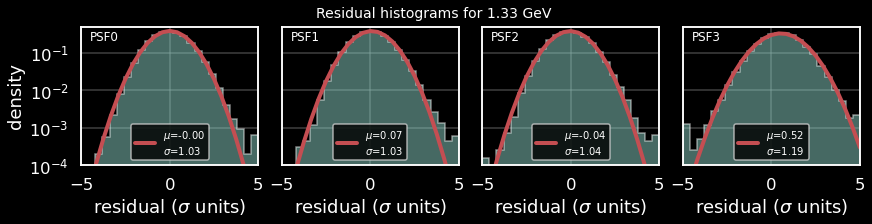

In [2]:
show(f'## plot residuals_for {pixel_table(0,(energy_index:=4)).energy} ')
show_fig(plot_residuals_for_given_energy,pixel_table, energy_index)   
show_fig(histograms_of_residuals_for_given_energy,pixel_table, energy_index)

In [3]:
reload(kerr_funcs); from pylib.kerr_funcs import ResidualPoints
self = ResidualPoints(pixel_table, energy_index=energy_index)

self.df.describe()

,pixel,data,model,sigma,glon,glat,psf,nside
count,188.000000,188.000000,188.000000,188.000000,188.000000,188.000000,188.000000,188.000000
mean,319467.148936,1510.228723,1304.955479,6.929746,-8.727927,3.440485,2.648936,228.425532
std,228324.213763,4668.816442,4239.229653,4.040029,108.334218,42.002258,0.823550,59.218347
min,3967.000000,6.000000,0.914720,5.001661,-175.429688,-86.161712,0.000000,64.000000
25%,94605.750000,10.000000,1.927054,5.223226,-101.023996,-30.518231,3.000000,256.000000
50%,301118.500000,57.000000,26.082821,5.656355,-3.691406,1.044512,3.000000,256.000000
75%,496775.750000,584.250000,464.891962,6.973574,87.916067,32.708594,3.000000,256.000000
max,764128.000000,39815.000000,38598.181295,38.612966,179.648438,83.417689,3.000000,256.000000


In [50]:
show(fr"""### Group the $\sigma>5$ residuals into clusters of nearby points
     Cluster adius= {(radius:=1.5)}. Select those with at least {(ptmin:=2)} points""")
cluster_idx = grouper(self.skycoord, radius)
# select only clusters with more than 1 point
clgt1 = list(filter(lambda x: len(x)>=ptmin, cluster_idx))

# make a list of the skycoords of the clusters, choosing the point with largest flux as the cluster center
cld = dict() #glat=[]; glon=[]
for idx, cluster in enumerate(clgt1):
    t = self.df.iloc[clgt1[idx]].sort_values('model', ascending=False).iloc[0]
    cld[idx] = dict(glon=round(t.glon,3), glat=round(t.glat,3), n=len(clgt1[idx]), 
                    sigma=round(t.sigma,1), data=t.data, model=round(t.model,1), ids=clgt1[idx])  
    
cldf = pd.DataFrame.from_dict(cld, orient='index')['glon glat data model sigma n ids'.split()]
cldf


### Group the $\sigma>5$ residuals into clusters of nearby points
Cluster adius= 1.5. Select those with at least 2 points

,glon,glat,data,model,sigma,n,ids
0,85.000,83.418,218.0,147.3,5.8,8,"[0, 38, 37, 36, 35, 21, 20, 11]"
1,-38.672,17.270,1323.0,989.8,10.6,9,"[1, 89, 88, 87, 27, 26, 25, 14, 13]"
2,-164.883,4.182,17908.0,16391.7,11.8,12,"[2, 101, 5, 4, 100, 99, 98, 97, 96, 28, 15, 3]"
3,-96.328,-2.687,39815.0,38598.2,6.2,8,"[6, 129, 8, 127, 125, 123, 29, 7]"
4,127.969,-30.692,165.0,108.1,5.5,7,"[9, 150, 149, 148, 147, 32, 31]"
5,-71.250,-63.448,93.0,52.2,5.6,3,"[10, 178, 34]"
6,99.844,-31.039,74.0,35.5,6.5,4,"[17, 153, 152, 18]"
7,-160.714,78.468,240.0,162.9,6.0,2,"[41, 43]"
8,49.821,64.199,9.0,1.9,5.2,2,"[48, 49]"
9,63.457,41.014,100.0,59.3,5.3,2,"[69, 70]"


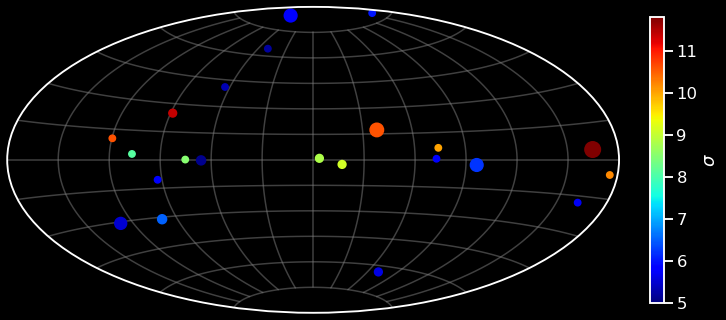

In [51]:
clpoints = SkyCoord(cldf.glon, cldf.glat, unit='deg', frame='galactic')
(AITfigure(figsize=(10,10))
    .scatter(clpoints, s=cldf.n*20, c=cldf.sigma, cmap='jet', vmin=5)
    .colorbar(label=r'$\sigma$', shrink=0.4)
    .show())

In [6]:
from utilities.catalogs import UWcat, Fermi4FGL
show(f""" ## Compare with {(fglname:='uw1617')}""")
fgl = Fermi4FGL(fglname)
# for test in ResidualPoints(pixel_table(1,4)).points:
#     t  = fgl.catalog_entry(test, 1)
#     if t is not None:
#         print(t.name, round(t.ts),  round(t.sep,1))

## Compare with uw1617

Loaded Fermi 4FGL gll_pscP305uw1617_v4_assoc_v9r1_classes.fits: 7221 entries


<utilities.ipynb_docgen.doc_formatter.<locals>.MimeBundleObject at 0xf540d715b6e0>
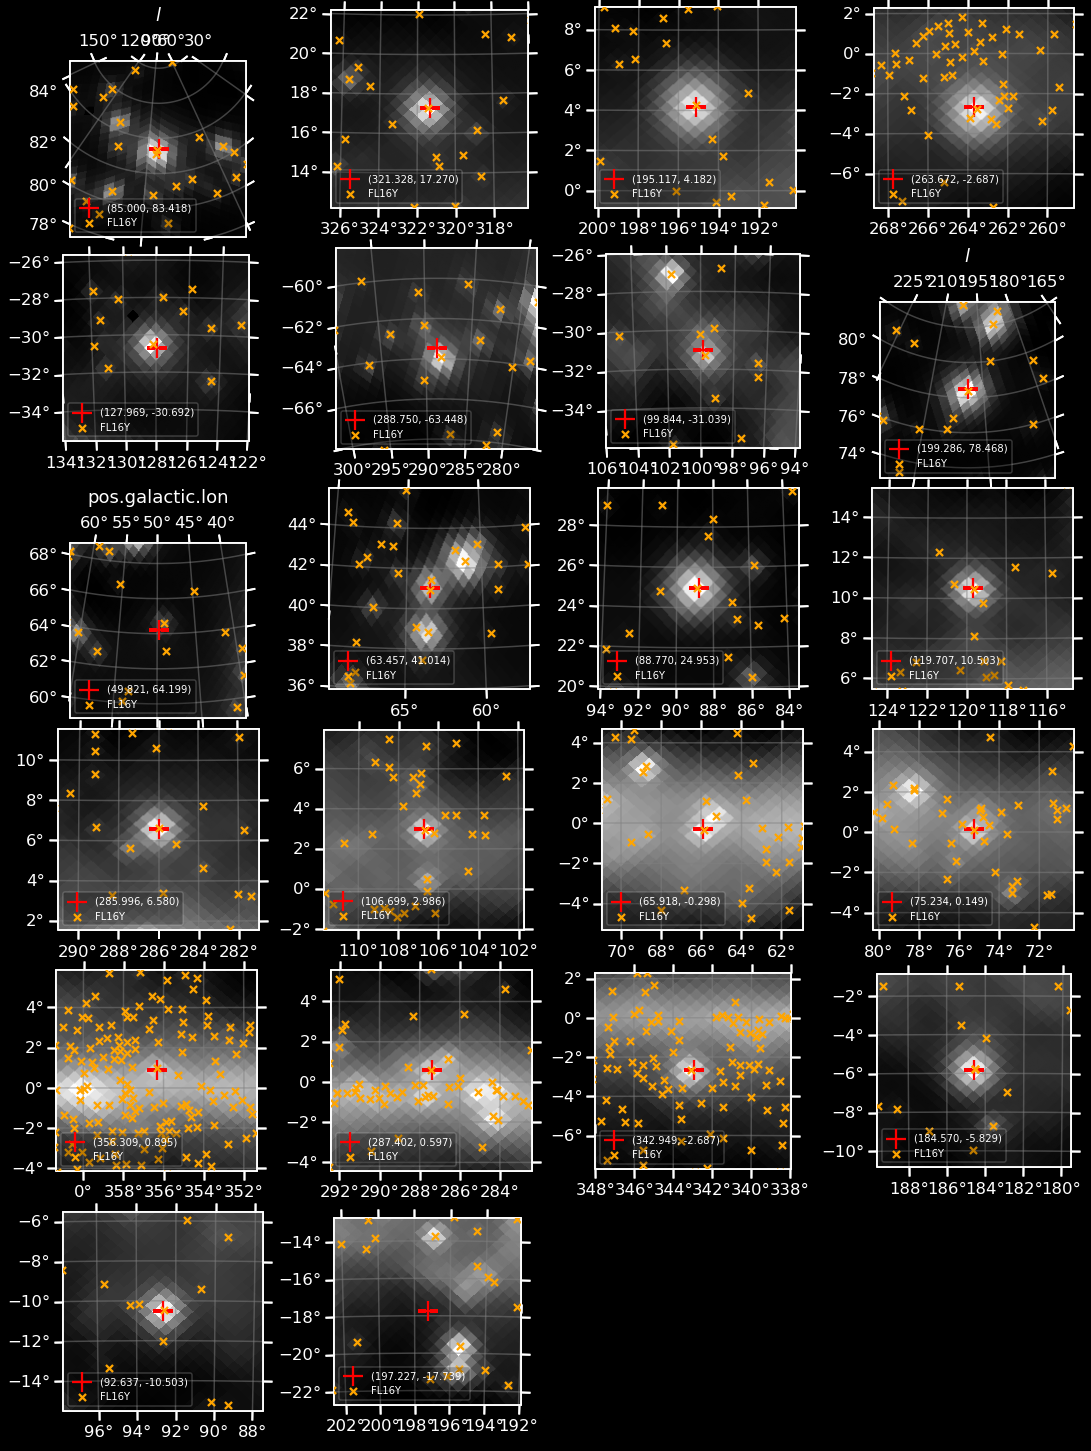

In [ ]:
def residual_scatter(band, center,*, component='model', fig=None, figsize=(8,8),**kwargs):
    
    (band.zea_plot(center=center, component=component, size=10, cmap='gist_gray',title='',
        fig=fig,figsize=figsize,  **kwargs)  
        .scatter(center,marker='+',color='red',s=400, 
                label=f'({center.l.deg:.3f}, {center.b.deg:.3f})')
        .scatter(fgl, marker='x',s=50, color='orange', label='FL16Y')
        .legend(loc='lower left',fontsize=10, framealpha=0.25)
    )
    if fig is not None: plt.gca().set(xlabel='',ylabel='')
    if fig is None: plt.show()

fig = plt.figure(figsize=(15,20))
subfigs = fig.subfigures(6,4)
for point, sfig in zip(clpoints, subfigs.flat):
    residual_scatter(band, point, fig=sfig, colorbar=False, )
show(fig)

### Residual check plots with model<100 

,glon,glat,n,sigma,data,model,ids
5,-71.250,-63.448,3,5.6,93.0,52.2,"[10, 178, 34]"
6,99.844,-31.039,4,6.5,74.0,35.5,"[17, 153, 152, 18]"
8,49.821,64.199,2,5.2,9.0,1.9,"[48, 49]"
9,63.457,41.014,2,5.3,100.0,59.3,"[69, 70]"
21,-162.773,-17.739,2,5.7,12.0,2.6,"[137, 139]"


<utilities.ipynb_docgen.doc_formatter.<locals>.MimeBundleObject at 0xf540b3dc3380>
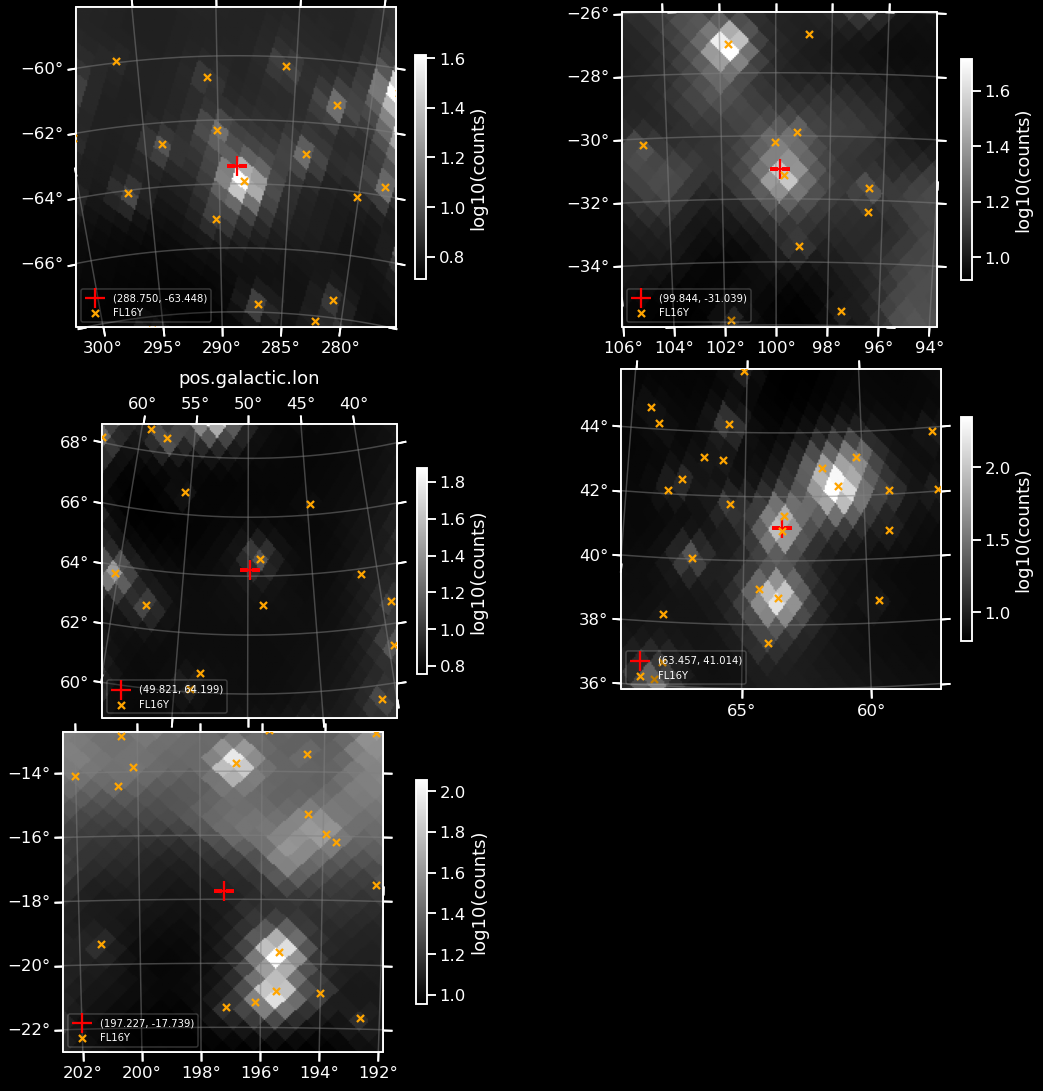

In [47]:
show(f"""### Residual check plots with model<100 """)
fig = plt.figure(figsize=(15,15))
subfigs = fig.subfigures(3,2)

df = cldf.query('model<100'); show(df)
for point, sfig in zip(SkyCoord(df.glon, df.glat, unit='deg',frame='galactic'), subfigs.flat):
    residual_scatter(band, point, component='model', fig=sfig, colorbar=True, )
show(fig)

In [10]:

show(f""" ## Compare with {(uwname:='uw1618')}""")
from utilities.catalogs import UWcat, Fermi4FGL
uw = UWcat(uwname)
for test in ResidualPoints(pixel_table(1,2)).points:
    t  = uw.catalog_entry(test, 1)
    if t is not None:
        print(t.name, round(t.ts),  round(t.sep,1))

## Compare with uw1618

Loaded UW model uw1618: 12082 entries


TypeError: ResidualPoints.__init__() missing 1 required positional argument: 'energy_index'

In [ ]:
assert False
multi_residual_plotter(self, nside=64)
for i in range(0,6):
    ResidualPlotter(self(2,i), 64).plots()
for i in range(0,6):
    ResidualPlotter(self(3,i)).plots()

AssertionError: 

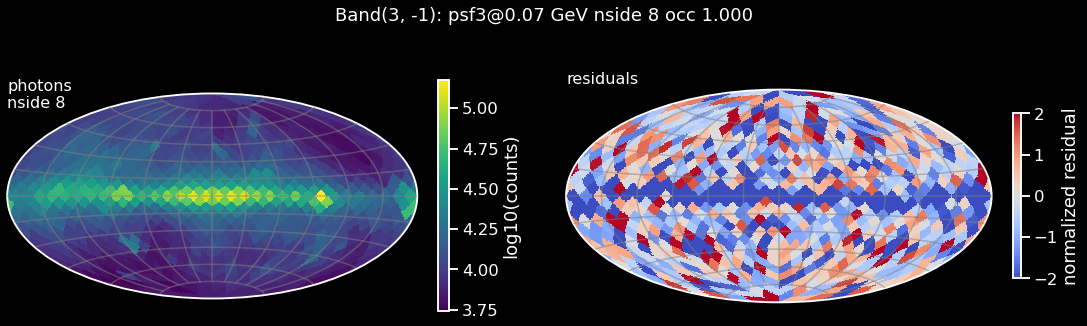

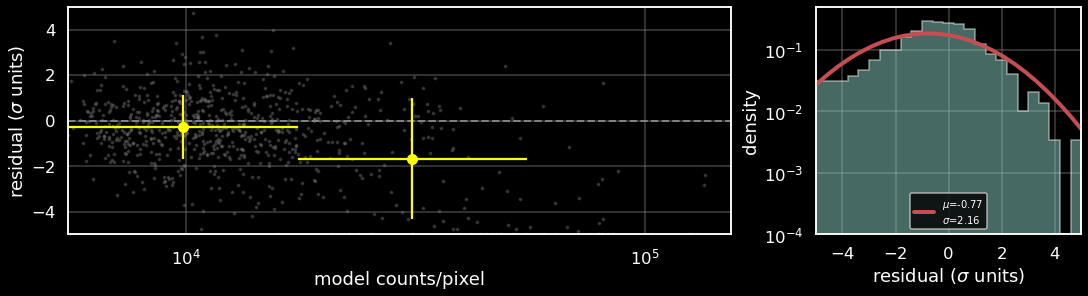

In [ ]:
ResidualPlotter(self(3,-1), 64).plots()

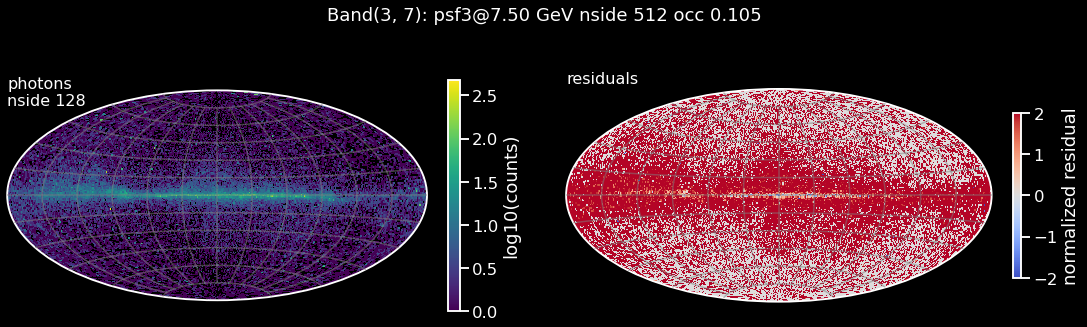

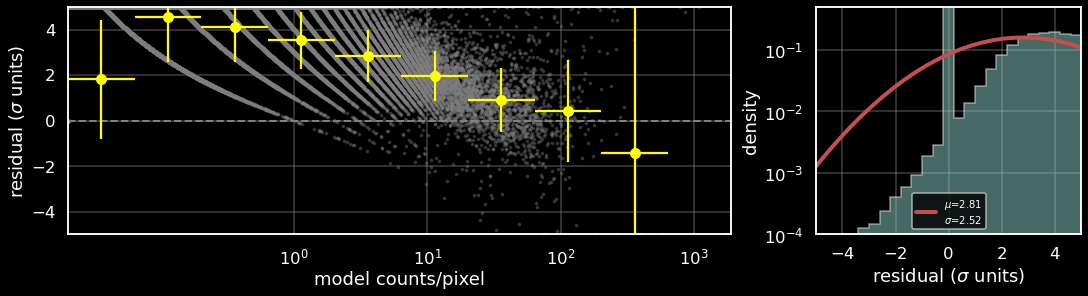

In [ ]:
ResidualPlotter(self(3,7), 128).plots()

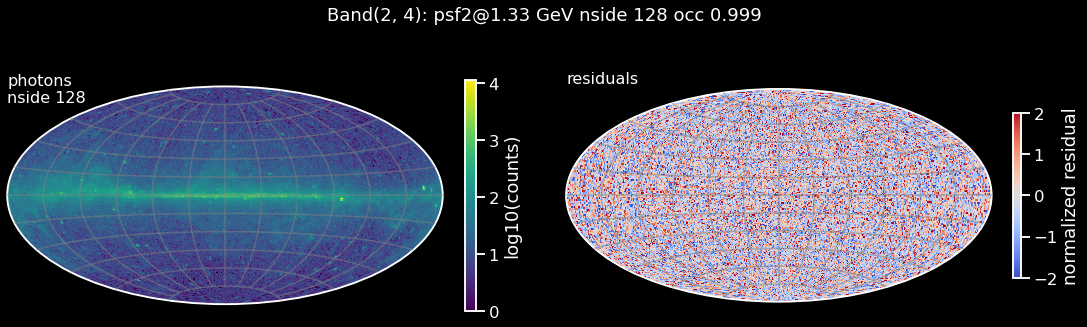

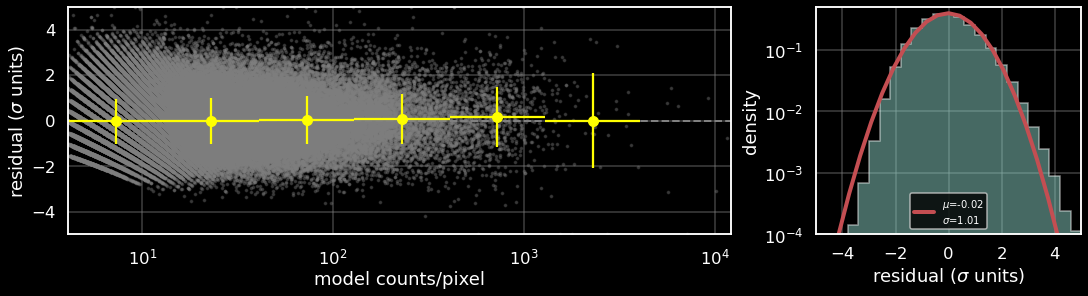

In [ ]:
ResidualPlotter(self(2,4), 128).plots()